In [ ]:
import tensorflow as tf         # Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [ ]:
x_train = x_train / 255.0    # Normalize the images
x_test = x_test / 255.0

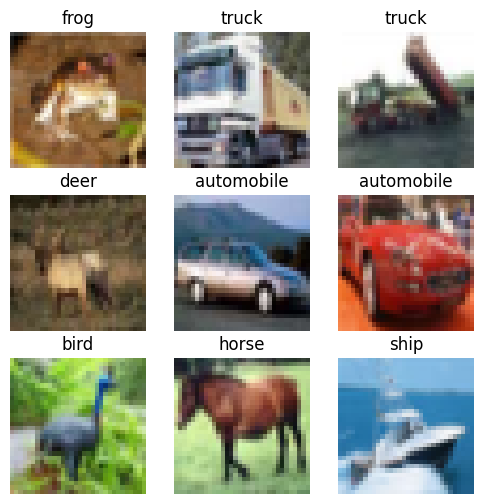

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(6,6))      # Visualize sample images

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [ ]:
datagen = ImageDataGenerator(             # Data Augmentation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [ ]:
model = Sequential()       #Build CNN Model (LeNet - Style)

# Convolution Layer
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(BatchNormalization())

# Pooling
model.add(MaxPooling2D((2,2)))

# Second Convolution
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Third Convolution
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))

model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(      # Compile the model
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(       # Train the Model
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 50ms/step - accuracy: 0.3649 - loss: 1.7300 - val_accuracy: 0.5119 - val_loss: 1.3251
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.5006 - loss: 1.3902 - val_accuracy: 0.5928 - val_loss: 1.1371
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.5666 - loss: 1.2296 - val_accuracy: 0.6158 - val_loss: 1.1114
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.6116 - loss: 1.1126 - val_accuracy: 0.5886 - val_loss: 1.1823
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.6421 - loss: 1.0341 - val_accuracy: 0.6977 - val_loss: 0.8661
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.6602 - loss: 0.9906 - val_accuracy: 0.7037 - val_loss: 0.8675
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6795 - loss: 0.9340 - val_accuracy: 0.6744 - val_loss: 0.9682
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.6872 - loss: 0.9164 - 

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)      # Evaluate Model

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7534 - loss: 0.7316
Test Accuracy: 0.7534000277519226


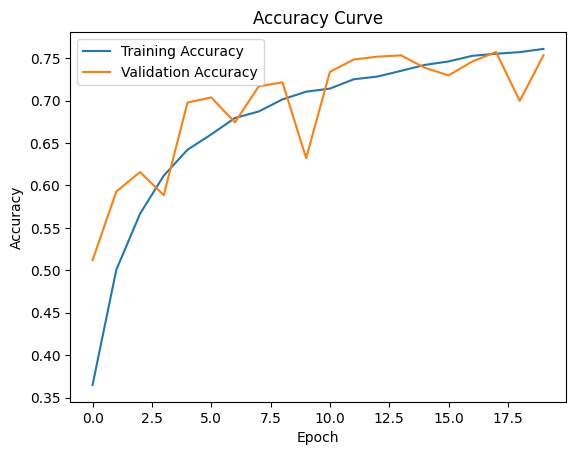

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

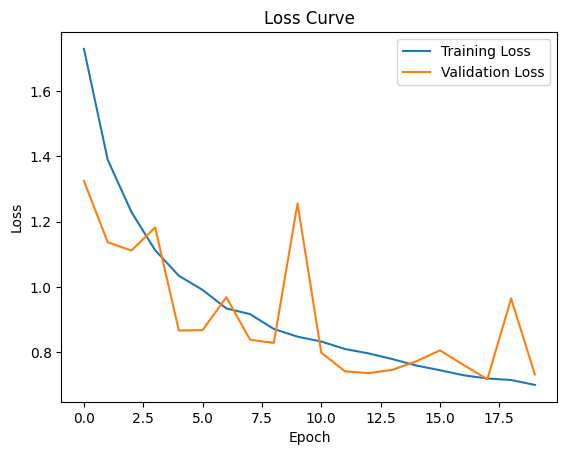

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()